# EDA Tasks — Cafe Sales cleaned data
### Student: Muhammad Faizan
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

df = pd.read_csv("cleaned_cafe_sales.csv")
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (9540, 9)

Columns: ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Transaction Label']

First 5 rows:


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Transaction Label
0,TXN_1961373,Coffee,2.0,2.0,4.000000,Credit Card,Takeaway,2023-09-08,Low
1,TXN_4977031,Cake,4.0,3.0,12.000000,Cash,In-Store,2023-05-16,High
2,TXN_4271903,Cookie,4.0,1.0,8.914442,Credit Card,In-Store,2023-07-19,High
3,TXN_7034554,Salad,2.0,5.0,10.000000,Unknown,Unknown,2023-04-27,High
4,TXN_3160411,Coffee,2.0,2.0,4.000000,Digital Wallet,In-Store,2023-06-11,Low


## Q1. How is customer spending distributed? Are most transactions low or high value?

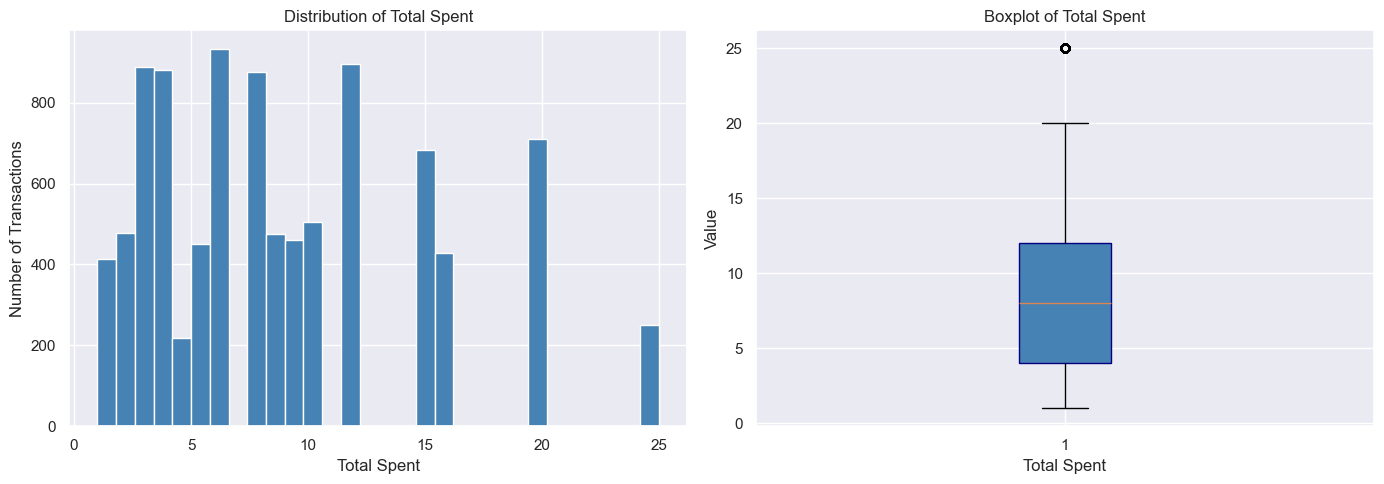

Mean   : 8.91
Median : 8.00

📝 Most transactions are low-to-mid value. The median is lower than the mean, indicating a few high-value transactions skew the distribution upward.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Total Spent'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Total Spent')
axes[0].set_xlabel('Total Spent')
axes[0].set_ylabel('Number of Transactions')

axes[1].boxplot(df['Total Spent'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot of Total Spent')
axes[1].set_xlabel('Total Spent')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

print(f"Mean   : {df['Total Spent'].mean():.2f}")
print(f"Median : {df['Total Spent'].median():.2f}")
print(f"\n📝 Most transactions are low-to-mid value. The median is lower than the mean, indicating a few high-value transactions skew the distribution upward.")

## Q2. Does the quantity ordered per transaction vary a lot or stay consistent?

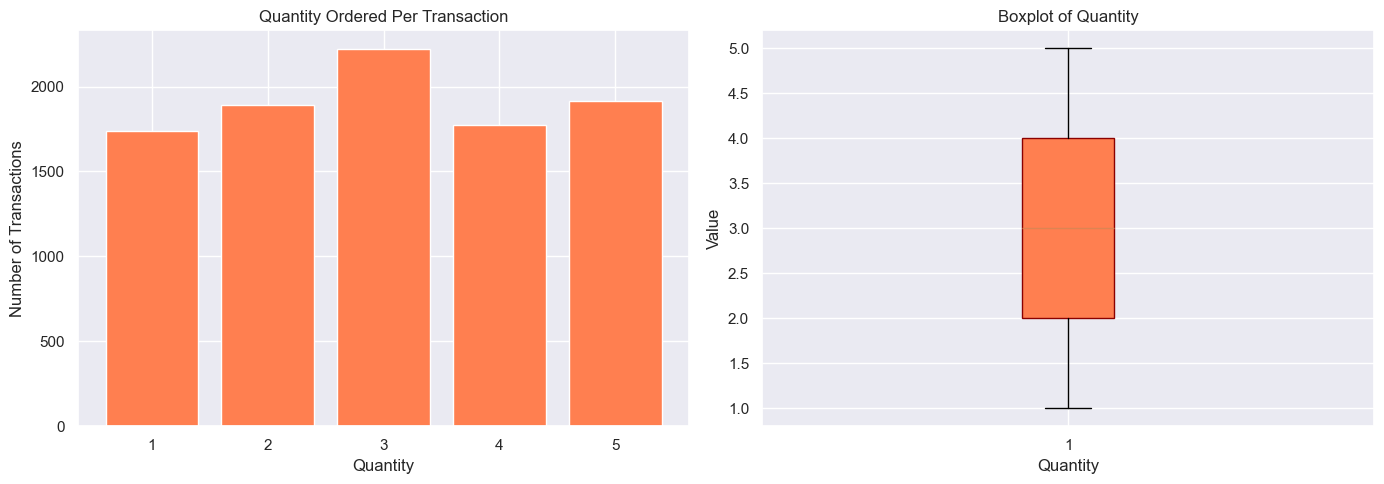

Std Dev : 1.38
Min: 1  |  Max: 5  |  Mean: 3.02

📝 Quantity stays fairly consistent — most customers order between 1 to 3 items with low variation across transactions.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quantity_counts = df['Quantity'].value_counts().sort_index()
axes[0].bar(quantity_counts.index, quantity_counts.values, color='coral', edgecolor='white')
axes[0].set_title('Quantity Ordered Per Transaction')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Number of Transactions')

axes[1].boxplot(df['Quantity'], patch_artist=True,
                boxprops=dict(facecolor='coral', color='darkred'))
axes[1].set_title('Boxplot of Quantity')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

print(f"Std Dev : {df['Quantity'].std():.2f}")
print(f"Min: {df['Quantity'].min():.0f}  |  Max: {df['Quantity'].max():.0f}  |  Mean: {df['Quantity'].mean():.2f}")
print("\n📝 Quantity stays fairly consistent — most customers order between 1 to 3 items with low variation across transactions.")

## Q3. Which item brings most total revenue — and is it also ordered most frequently?

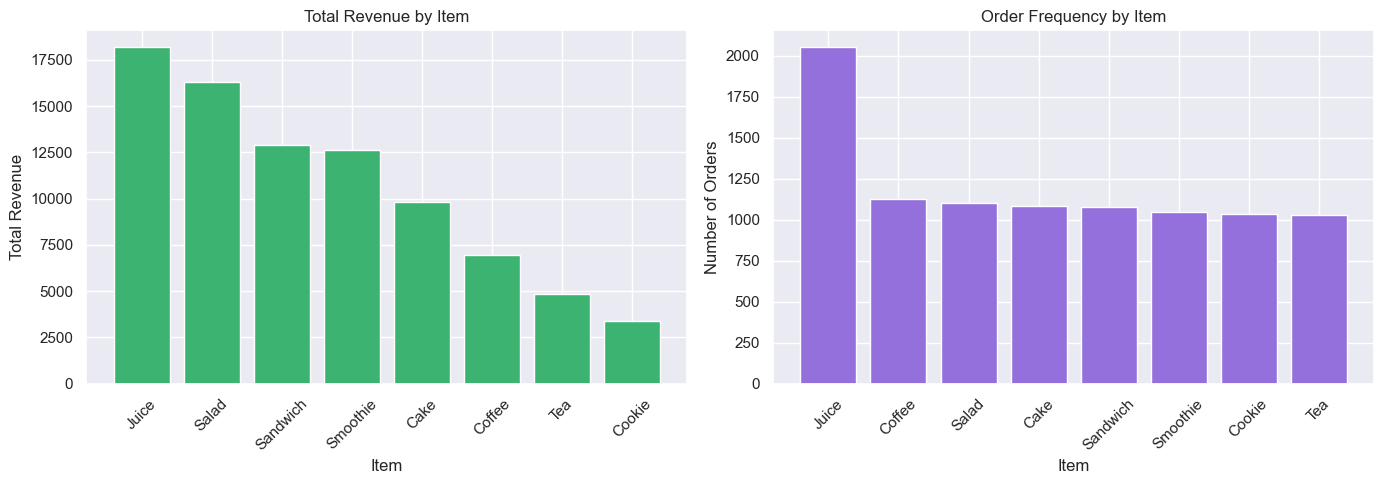

Highest Revenue Item : Juice  —  18179.36
Most Ordered Item    : Juice  —  2051 orders
Same item? ✅ Yes

📝 The highest revenue item may differ from the most frequently ordered one — price per unit plays a key role in total revenue.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

revenue = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)
axes[0].bar(revenue.index, revenue.values, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Total Revenue by Item')
axes[0].set_xlabel('Item')
axes[0].set_ylabel('Total Revenue')
axes[0].tick_params(axis='x', rotation=45)

frequency = df['Item'].value_counts()
axes[1].bar(frequency.index, frequency.values, color='mediumpurple', edgecolor='white')
axes[1].set_title('Order Frequency by Item')
axes[1].set_xlabel('Item')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Highest Revenue Item : {revenue.idxmax()}  —  {revenue.max():.2f}")
print(f"Most Ordered Item    : {frequency.idxmax()}  —  {frequency.max()} orders")
same = revenue.idxmax() == frequency.idxmax()
print(f"Same item? {'✅ Yes' if same else '❌ No — different items lead in revenue vs frequency'}")
print("\n📝 The highest revenue item may differ from the most frequently ordered one — price per unit plays a key role in total revenue.")

## Q4. What does the breakdown of payment methods look like?

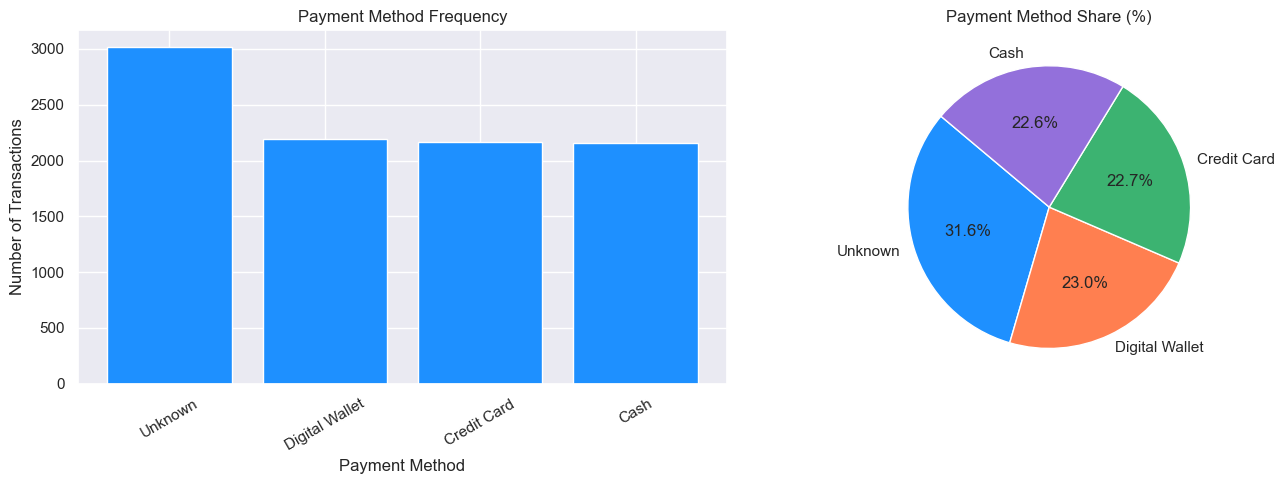

Payment Method
Unknown           3015
Digital Wallet    2197
Credit Card       2170
Cash              2158
Name: count, dtype: int64

📝 Unknown is the most preferred payment method with 3015 transactions.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

payment_counts = df['Payment Method'].value_counts()

axes[0].bar(payment_counts.index, payment_counts.values, color='dodgerblue', edgecolor='white')
axes[0].set_title('Payment Method Frequency')
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(payment_counts.values, labels=payment_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=['dodgerblue','coral','mediumseagreen','mediumpurple','gold'])
axes[1].set_title('Payment Method Share (%)')

plt.tight_layout()
plt.show()

print(payment_counts)
print(f"\n📝 {payment_counts.idxmax()} is the most preferred payment method with {payment_counts.max()} transactions.")

## Q5. Does ordering more quantity always mean spending more?

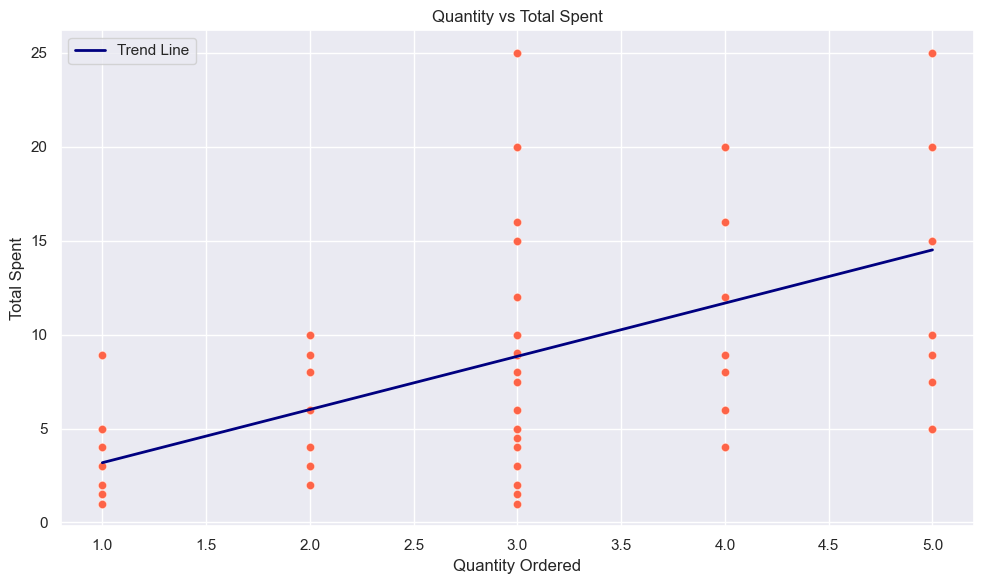

Correlation between Quantity and Total Spent: 0.6694

📝 There is a positive relationship — more quantity generally leads to higher spending. However, it's not perfectly linear because different items have different prices.


In [6]:
plt.figure(figsize=(10, 6))

plt.scatter(df['Quantity'], df['Total Spent'],
            alpha=0.4, color='tomato', edgecolors='white', linewidths=0.5)

z = np.polyfit(df['Quantity'], df['Total Spent'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Quantity'].min(), df['Quantity'].max(), 100)
plt.plot(x_line, p(x_line), color='navy', linewidth=2, label='Trend Line')

plt.title('Quantity vs Total Spent')
plt.xlabel('Quantity Ordered')
plt.ylabel('Total Spent')
plt.legend()
plt.tight_layout()
plt.show()

corr = df['Quantity'].corr(df['Total Spent'])
print(f"Correlation between Quantity and Total Spent: {corr:.4f}")
print("\n📝 There is a positive relationship — more quantity generally leads to higher spending. However, it's not perfectly linear because different items have different prices.")

## Q6. How correlated are the numerical columns with each other?

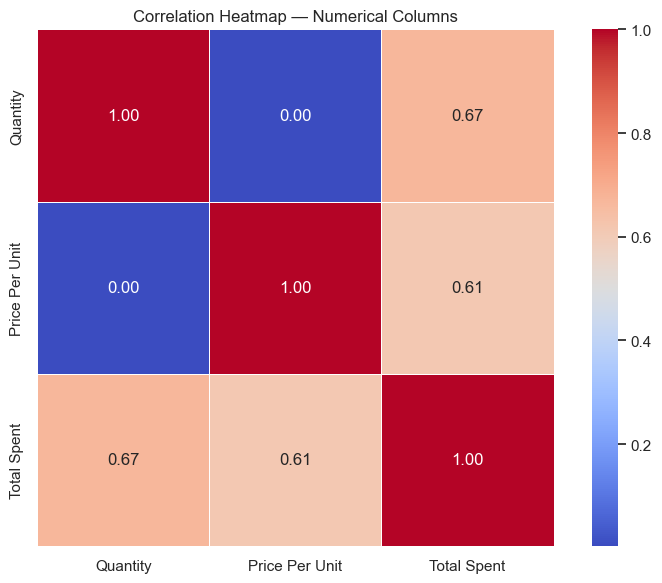

                Quantity  Price Per Unit  Total Spent
Quantity        1.000000        0.003769     0.669378
Price Per Unit  0.003769        1.000000     0.611979
Total Spent     0.669378        0.611979     1.000000

📝 Total Spent and Price Per Unit show strong positive correlation — this is expected since Total = Price x Quantity. Quantity shows moderate correlation with Total Spent.


In [7]:
plt.figure(figsize=(8, 6))

numerical_cols = df.select_dtypes(include=np.number)
corr_matrix = numerical_cols.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)

plt.title('Correlation Heatmap — Numerical Columns')
plt.tight_layout()
plt.show()

print(corr_matrix)
print("\n📝 Total Spent and Price Per Unit show strong positive correlation — this is expected since Total = Price x Quantity. Quantity shows moderate correlation with Total Spent.")

## Q7. Does location or payment method influence spending per transaction?

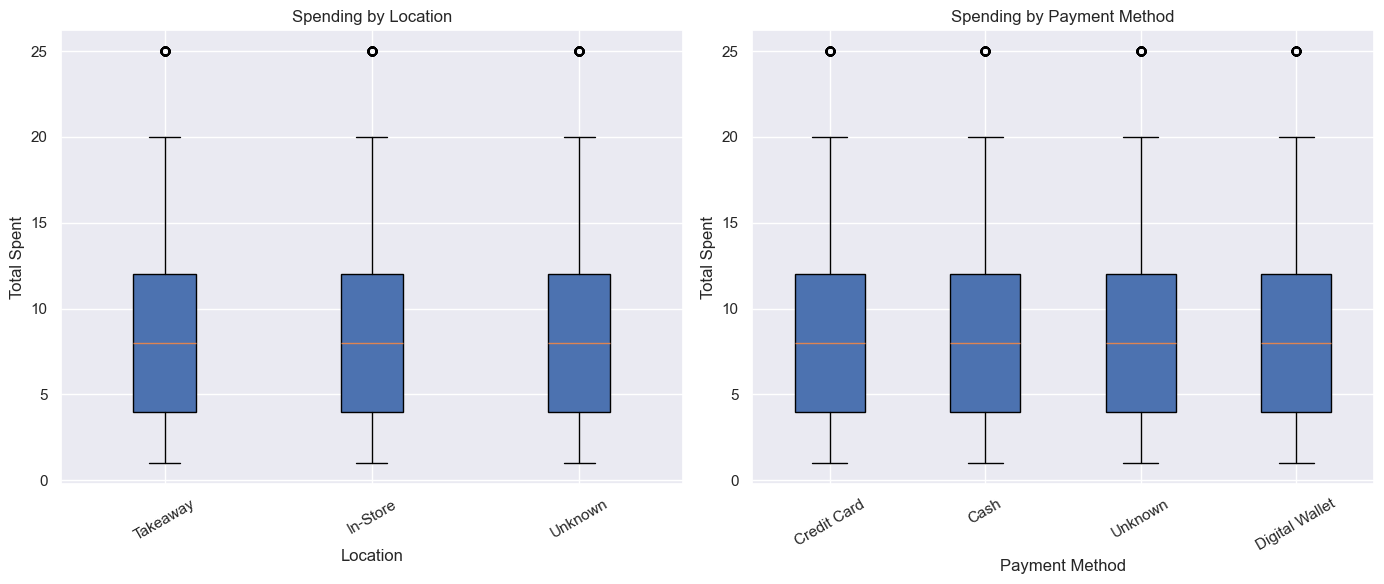

Average Spending by Location:
Location
In-Store    9.03
Takeaway    8.79
Unknown     8.92
Name: Total Spent, dtype: float64

Average Spending by Payment Method:
Payment Method
Cash              9.06
Credit Card       9.00
Digital Wallet    8.93
Unknown           8.73
Name: Total Spent, dtype: float64

📝 Location and payment method show slight differences in average spending. Some payment methods tend to be used for higher-value purchases.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

locations = df['Location'].unique()
location_data = [df[df['Location'] == loc]['Total Spent'].dropna().values for loc in locations]
axes[0].boxplot(location_data, labels=locations, patch_artist=True)
axes[0].set_title('Spending by Location')
axes[0].set_xlabel('Location')
axes[0].set_ylabel('Total Spent')
axes[0].tick_params(axis='x', rotation=30)

payments = df['Payment Method'].unique()
payment_data = [df[df['Payment Method'] == pm]['Total Spent'].dropna().values for pm in payments]
axes[1].boxplot(payment_data, labels=payments, patch_artist=True)
axes[1].set_title('Spending by Payment Method')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Total Spent')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("Average Spending by Location:")
print(df.groupby('Location')['Total Spent'].mean().round(2))
print("\nAverage Spending by Payment Method:")
print(df.groupby('Payment Method')['Total Spent'].mean().round(2))
print("\n📝 Location and payment method show slight differences in average spending. Some payment methods tend to be used for higher-value purchases.")

## Q8. How does total revenue change over time? (Monthly)

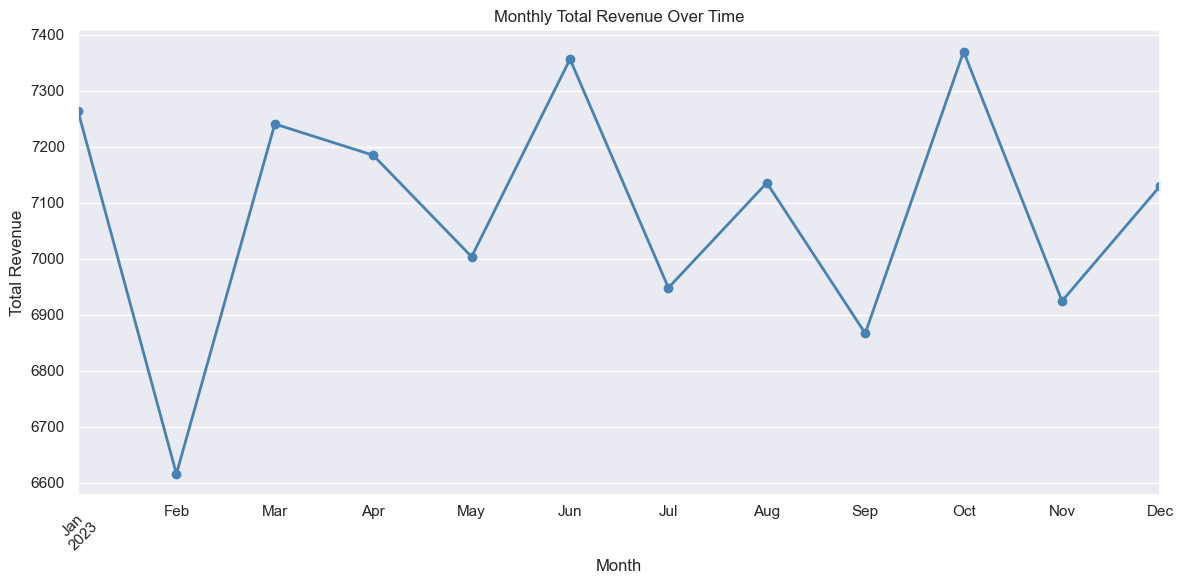

Monthly Revenue:
Month
2023-01    7263.978762
2023-02    6616.005461
2023-03    7240.978762
2023-04    7185.136529
2023-05    7003.834345
2023-06    7356.762136
2023-07    6948.406553
2023-08    7135.775485
2023-09    6866.992112
2023-10    7370.334345
2023-11    6924.735437
2023-12    7130.834345
Freq: M, Name: Total Spent, dtype: float64

Best Month : 2023-10 — 7370.33
Worst Month: 2023-02 — 6616.01

📝 Monthly time unit chosen — daily view is too noisy, yearly loses important detail. Monthly clearly shows seasonal revenue trends for the cafe.


In [9]:
df['Month'] = df['Transaction Date'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Total Spent'].sum()

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='o', color='steelblue', linewidth=2, markersize=6)
plt.title('Monthly Total Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Monthly Revenue:")
print(monthly_revenue)
print(f"\nBest Month : {monthly_revenue.idxmax()} — {monthly_revenue.max():.2f}")
print(f"Worst Month: {monthly_revenue.idxmin()} — {monthly_revenue.min():.2f}")
print("\n📝 Monthly time unit chosen — daily view is too noisy, yearly loses important detail. Monthly clearly shows seasonal revenue trends for the cafe.")

## Q9. Most Interesting Visualization — Revenue by Item (Replotted)

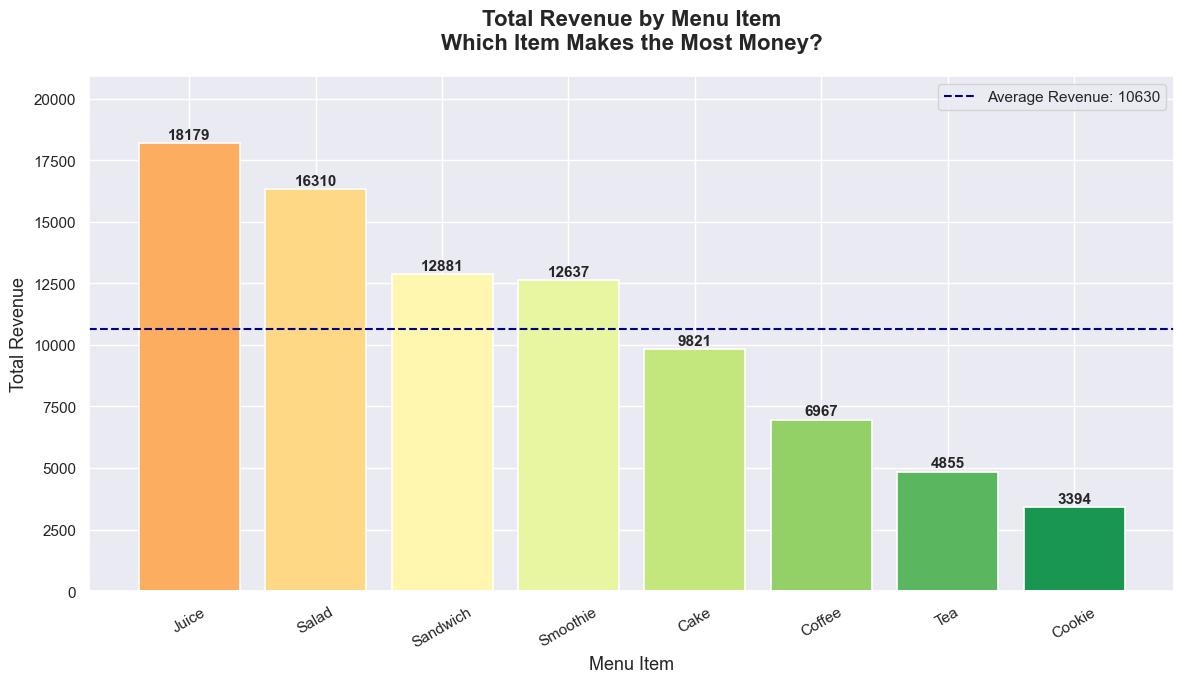


📊 What a Cafe Owner Can Learn:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. The top revenue item should always be well-stocked and promoted on the menu.
2. Items below the average revenue line are underperforming and may need discounts or removal.
3. A small number of items drive most of the total revenue (Pareto principle applies).
4. Marketing budget should focus on top 2-3 items for maximum return on investment.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [10]:
fig, ax = plt.subplots(figsize=(12, 7))

revenue = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(revenue)))

bars = ax.bar(revenue.index, revenue.values, color=colors, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Total Revenue by Menu Item\nWhich Item Makes the Most Money?',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Menu Item', fontsize=13)
ax.set_ylabel('Total Revenue', fontsize=13)
ax.tick_params(axis='x', rotation=30, labelsize=11)
ax.set_ylim(0, revenue.max() * 1.15)
ax.axhline(y=revenue.mean(), color='navy', linestyle='--', linewidth=1.5,
           label=f'Average Revenue: {revenue.mean():.0f}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("""
📊 What a Cafe Owner Can Learn:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. The top revenue item should always be well-stocked and promoted on the menu.
2. Items below the average revenue line are underperforming and may need discounts or removal.
3. A small number of items drive most of the total revenue (Pareto principle applies).
4. Marketing budget should focus on top 2-3 items for maximum return on investment.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

---
## ✅ EDA Complete — Muhammad Faizan
*All 9 questions answered with visualizations and insights.*